In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [36]:
df = pd.read_excel('E_Commerce_Dataset[1].xlsx', sheet_name='E Comm')
print(df.columns)
print(df['Churn'].value_counts())
print(df.head())
print(df.isnull().sum())
# fill numerical NaNs with mean
numerical_cols = df.select_dtypes(include='number').columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].mean())
# fill categorical NaNs with mode
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')
Churn
0    4682
1     948
Name: count, dtype: int64
   CustomerID  Churn  Tenure  ... OrderCount  DaySinceLastOrder  CashbackAmount
0       50001      1     4.0  ...        1.0                5.0          159.93
1       50002      1     NaN  ...        1.0                0.0          120.90
2       50003      1     NaN  ...        1.0                3.0          120.28
3       50004      1     0.0  ...        1.0                3.0          134.07
4       50005      1     0.0  ...        1.0                3.0          129.60

[5 rows x 20 columns]
CustomerID               

In [37]:
df = df.drop(['CustomerID', 'NumberOfAddress','WarehouseToHome'], axis=1)

Churn                          1.000000
Tenure                        -0.335513
PreferredLoginDevice           0.013281
CityTier                       0.084703
PreferredPaymentMode          -0.026519
Gender                         0.029264
HourSpendOnApp                 0.018126
NumberOfDeviceRegistered       0.107939
PreferedOrderCat               0.118922
SatisfactionScore              0.105481
MaritalStatus                  0.140316
Complain                       0.250188
OrderAmountHikeFromlastYear   -0.009949
CouponUsed                    -0.008197
OrderCount                    -0.028342
DaySinceLastOrder             -0.156152
CashbackAmount                -0.154118
Name: Churn, dtype: float64


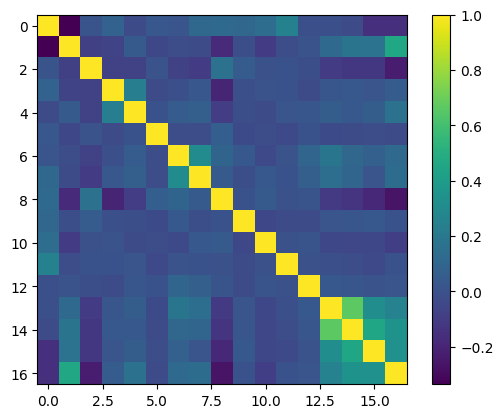

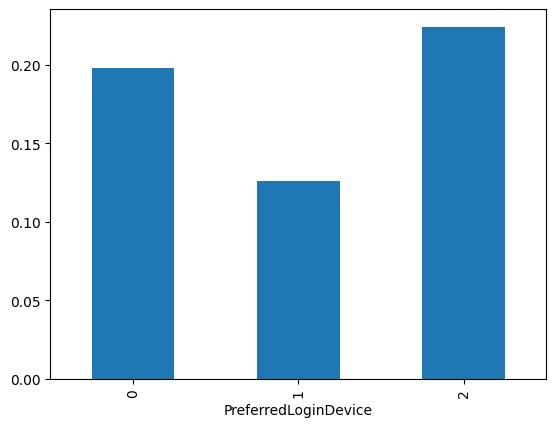

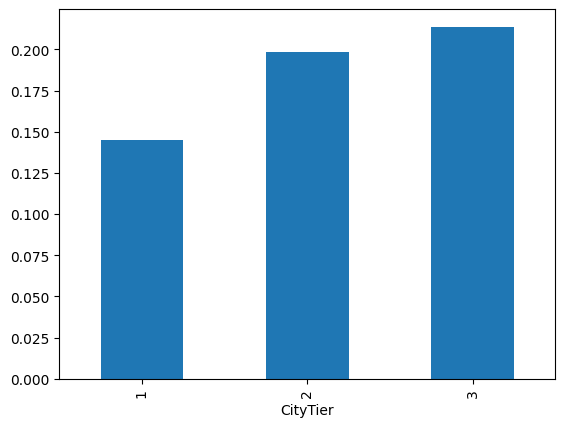

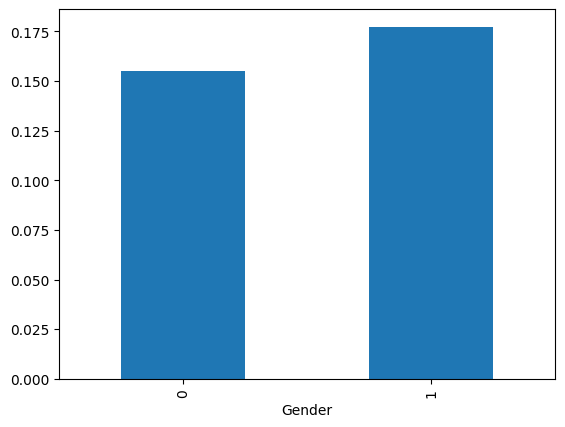

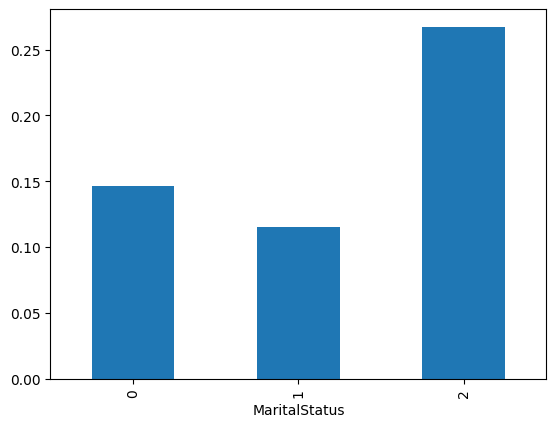

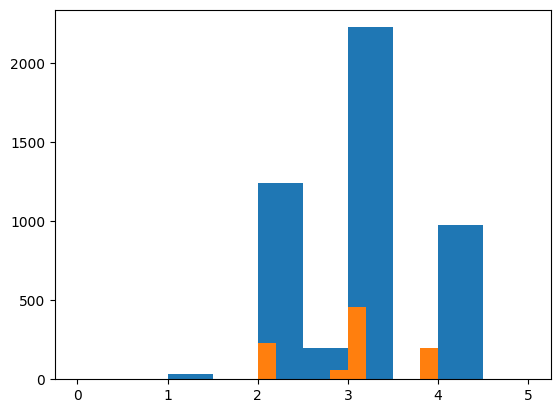

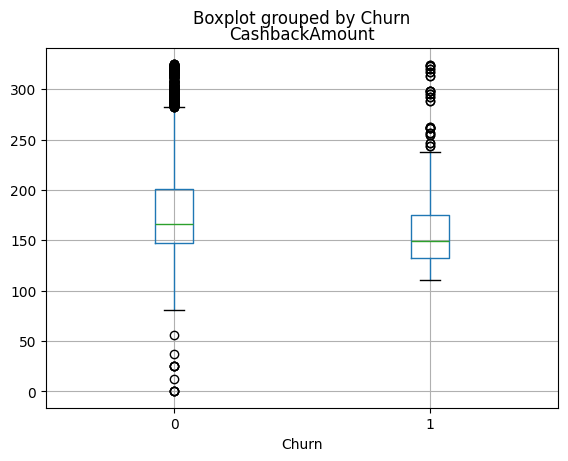

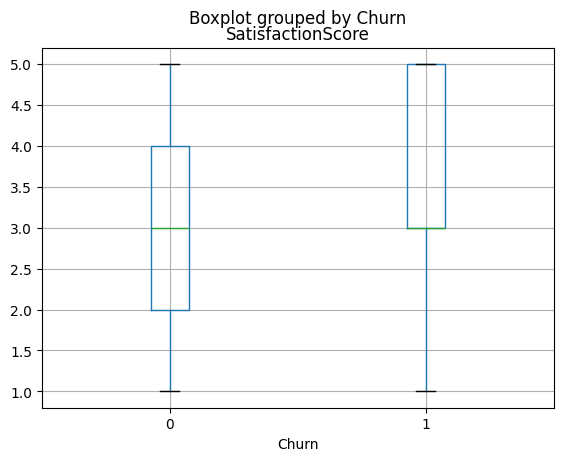

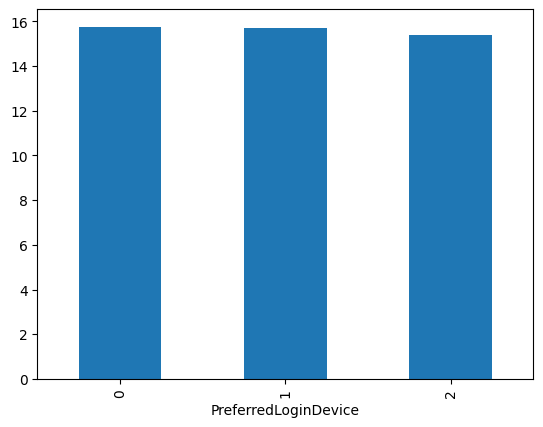

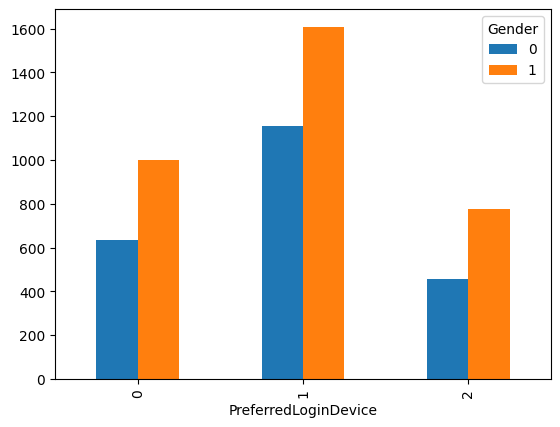

In [38]:


# correlation with churn
corr = df.corr(numeric_only=True)
print(corr['Churn'])

plt.imshow(corr)
plt.colorbar()
plt.show()

# churn rate by login device
df.groupby('PreferredLoginDevice')['Churn'].mean().plot(kind='bar')
plt.show()

# churn rate by city tier
df.groupby('CityTier')['Churn'].mean().plot(kind='bar')
plt.show()

# churn rate by gender
df.groupby('Gender')['Churn'].mean().plot(kind='bar')
plt.show()

# churn rate by marital status
df.groupby('MaritalStatus')['Churn'].mean().plot(kind='bar')
plt.show()

# hours on app by churn
churned = df[df['Churn'] == 1]
not_churned = df[df['Churn'] == 0]

plt.hist(not_churned['HourSpendOnApp'])
plt.hist(churned['HourSpendOnApp'])
plt.show()

# cashback amount by churn
df.boxplot(column='CashbackAmount', by='Churn')
plt.show()

# satisfaction score by churn
df.boxplot(column='SatisfactionScore', by='Churn')
plt.show()

# order amount hike by login device (churned only)
churned.groupby('PreferredLoginDevice')['OrderAmountHikeFromlastYear'].mean().plot(kind='bar')
plt.show()

# login device by gender
df.groupby(['PreferredLoginDevice', 'Gender']).size().unstack().plot(kind='bar')
plt.show()

In [39]:
X = df.drop('Churn', axis=1)
y = df['Churn']

 Train/Validation/Test Split

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (3378, 16)
Validation size: (1126, 16)
Test size: (1126, 16)


 Baseline Model

In [41]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, f1_score

baseline_model = LGBMClassifier(objective='binary', random_state=42)
baseline_model.fit(X_train, y_train)

val_preds = baseline_model.predict(X_val)
print("Baseline F1 score:", f1_score(y_val, val_preds))
print(classification_report(y_val, val_preds))

[LightGBM] [Info] Number of positive: 569, number of negative: 2809
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000760 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 410
[LightGBM] [Info] Number of data points in the train set: 3378, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.168443 -> initscore=-1.596703
[LightGBM] [Info] Start training from score -1.596703
Baseline F1 score: 0.7471910112359551
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       936
           1       0.80      0.70      0.75       190

    accuracy                           0.92      1126
   macro avg       0.87      0.83      0.85      1126
weighted avg       0.92      0.92      0.92      1126



Hyperparameter Grid

In [42]:
param_dist = {
    'num_leaves': [15, 31, 63, 127],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'boosting_type': ['gbdt', 'dart'],
    'max_depth': [-1, 5, 10, 15],
    'min_child_samples': [10, 20, 30, 50],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}

RandomizedSearch

In [43]:
from sklearn.model_selection import RandomizedSearchCV

model = LGBMClassifier(objective='binary', random_state=42)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best parameters found:", random_search.best_params_)
print("Best CV F1 score:", random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Info] Number of positive: 569, number of negative: 2809
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000146 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 410
[LightGBM] [Info] Number of data points in the train set: 3378, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.168443 -> initscore=-1.596703
[LightGBM] [Info] Start training from score -1.596703
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best parameters found: {'subsample': 1.0, 'num_leaves': 63, 'min_child_samples': 30, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.8, 'boosting_type': 'gbdt'}
Best CV F1 score: 0.8092103619505547


Evaluation on Validation Set

In [44]:
from sklearn.metrics import roc_auc_score

best_model = random_search.best_estimator_

val_preds = best_model.predict(X_val)
val_probs = best_model.predict_proba(X_val)[:, 1]

print("Tuned model F1 score:", f1_score(y_val, val_preds))
print("Tuned model ROC-AUC:", roc_auc_score(y_val, val_probs))
print(classification_report(y_val, val_preds))

Tuned model F1 score: 0.7796610169491526
Tuned model ROC-AUC: 0.9388326585695006
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       936
           1       0.84      0.73      0.78       190

    accuracy                           0.93      1126
   macro avg       0.89      0.85      0.87      1126
weighted avg       0.93      0.93      0.93      1126



Final Test Evaluation

In [45]:
from sklearn.metrics import confusion_matrix

test_preds = best_model.predict(X_test)
test_probs = best_model.predict_proba(X_test)[:, 1]

print("Final Test F1 score:", f1_score(y_test, test_preds))
print("Final Test ROC-AUC:", roc_auc_score(y_test, test_probs))
print(classification_report(y_test, test_preds))

cm = confusion_matrix(y_test, test_preds)
print("Confusion Matrix:")
print(cm)

Final Test F1 score: 0.8526315789473684
Final Test ROC-AUC: 0.965961387519552
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       937
           1       0.85      0.86      0.85       189

    accuracy                           0.95      1126
   macro avg       0.91      0.91      0.91      1126
weighted avg       0.95      0.95      0.95      1126

Confusion Matrix:
[[908  29]
 [ 27 162]]


Feature Importance Plot

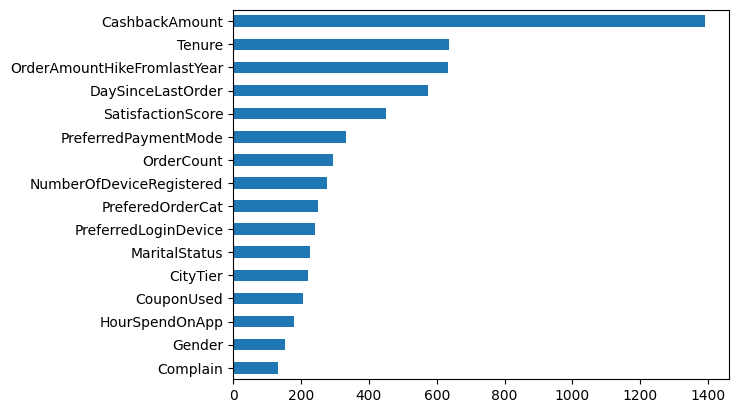

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

importances.head(16).plot(kind='barh')
plt.gca().invert_yaxis()
plt.show()